<a href="https://www.kaggle.com/code/sonawanelalitsunil/laptop-price-dataset-90-18?scriptVersionId=222947336" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/laptop-price-dataset/laptop_prices.csv


## laptop-price-dataset

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/laptop-price-dataset/laptop_prices.csv")

In [4]:
df.head()

,Brand,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Battery Life (hours),Weight (kg),Operating System,Price ($)
0,Apple,AMD Ryzen 3,64,512GB SSD,Nvidia GTX 1650,17.3,2560x1440,8.9,1.42,FreeDOS,3997.07
1,Razer,AMD Ryzen 7,4,1TB SSD,Nvidia RTX 3080,14.0,1366x768,9.4,2.57,Linux,1355.78
2,Asus,Intel i5,32,2TB SSD,Nvidia RTX 3060,13.3,3840x2160,8.5,1.74,FreeDOS,2673.07
3,Lenovo,Intel i5,4,256GB SSD,Nvidia RTX 3080,13.3,1366x768,10.5,3.10,Windows,751.17
4,Razer,Intel i3,4,256GB SSD,AMD Radeon RX 6600,16.0,3840x2160,5.7,3.38,Linux,2059.83


In [5]:
df.tail()

,Brand,Processor,RAM (GB),Storage,GPU,Screen Size (inch),Resolution,Battery Life (hours),Weight (kg),Operating System,Price ($)
11763,Acer,Intel i3,4,2TB SSD,Nvidia RTX 2060,17.3,1366x768,11.5,1.58,macOS,704.82
11764,Asus,Intel i3,4,2TB SSD,AMD Radeon RX 6800,16.0,1366x768,9.5,2.14,Linux,775.59
11765,Razer,AMD Ryzen 9,4,2TB SSD,AMD Radeon RX 6600,15.6,2560x1440,8.2,2.05,Linux,2789.46
11766,Samsung,AMD Ryzen 7,16,512GB SSD,Integrated,13.3,1920x1080,7.5,1.48,macOS,1067.13
11767,Samsung,Intel i7,8,256GB SSD,Nvidia RTX 3080,17.3,2560x1440,6.4,2.45,FreeDOS,1579.55


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11768 entries, 0 to 11767
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 11768 non-null  object 
 1   Processor             11768 non-null  object 
 2   RAM (GB)              11768 non-null  int64  
 3   Storage               11768 non-null  object 
 4   GPU                   11768 non-null  object 
 5   Screen Size (inch)    11768 non-null  float64
 6   Resolution            11768 non-null  object 
 7   Battery Life (hours)  11768 non-null  float64
 8   Weight (kg)           11768 non-null  float64
 9   Operating System      11768 non-null  object 
 10  Price ($)             11768 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1011.4+ KB


In [7]:
df.describe()

,RAM (GB),Screen Size (inch),Battery Life (hours),Weight (kg),Price ($)
count,11768.000000,11768.000000,11768.000000,11768.000000,11768.000000
mean,24.852821,15.212305,8.027855,2.341117,2183.571608
std,21.762567,1.436997,2.305400,0.667921,1316.886132
min,4.000000,13.300000,4.000000,1.200000,279.570000
25%,8.000000,14.000000,6.000000,1.760000,1272.045000
50%,16.000000,15.600000,8.000000,2.340000,1840.865000
75%,32.000000,16.000000,10.000000,2.910000,2698.370000
max,64.000000,17.300000,12.000000,3.500000,10807.880000


In [8]:
df.dtypes

Brand                    object
Processor                object
RAM (GB)                  int64
Storage                  object
GPU                      object
Screen Size (inch)      float64
Resolution               object
Battery Life (hours)    float64
Weight (kg)             float64
Operating System         object
Price ($)               float64
dtype: object

In [9]:
df.isnull().sum()

Brand                   0
Processor               0
RAM (GB)                0
Storage                 0
GPU                     0
Screen Size (inch)      0
Resolution              0
Battery Life (hours)    0
Weight (kg)             0
Operating System        0
Price ($)               0
dtype: int64

In [10]:
df.columns

Index(['Brand', 'Processor', 'RAM (GB)', 'Storage', 'GPU',
       'Screen Size (inch)', 'Resolution', 'Battery Life (hours)',
       'Weight (kg)', 'Operating System', 'Price ($)'],
      dtype='object')

In [11]:

from sklearn.preprocessing import LabelEncoder
categorical_features = ['Brand', 'Processor', 'GPU', 'Operating System']
for col in categorical_features:
    df[col] = LabelEncoder().fit_transform(df[col])

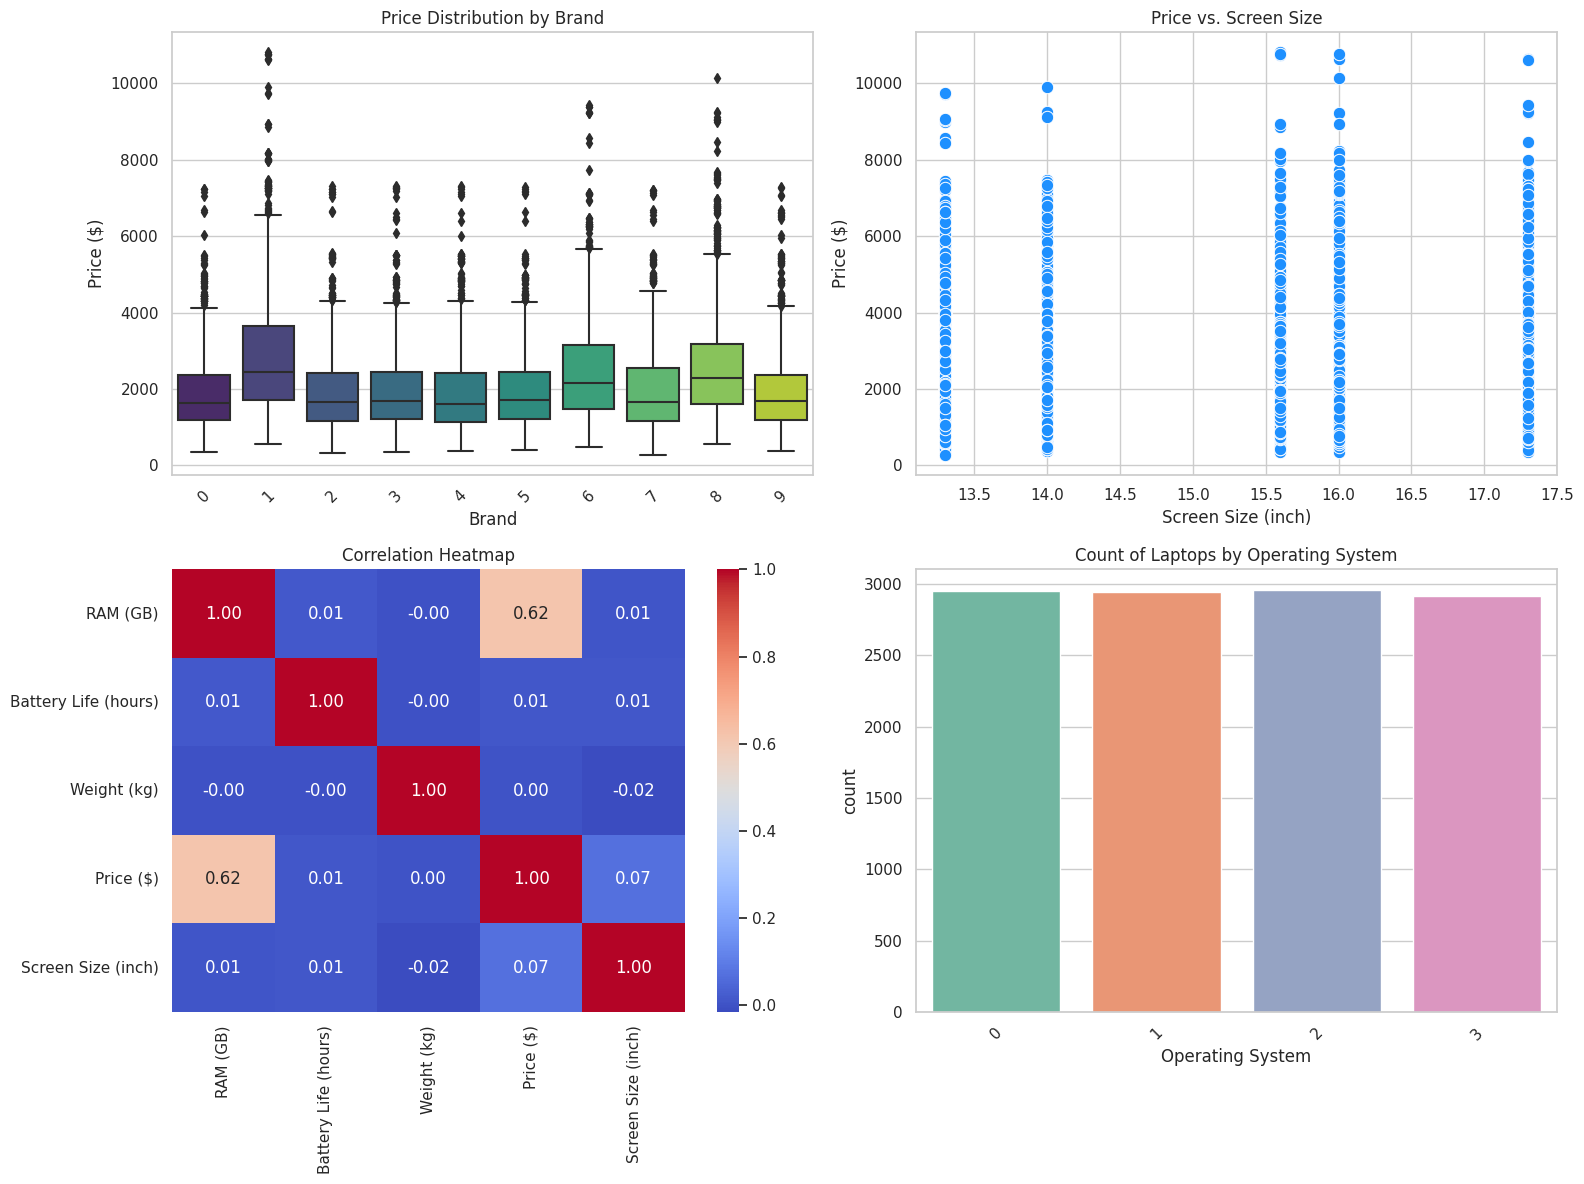

In [12]:

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot of Price vs. Brand (categorical vs. numerical)
sns.boxplot(data=df, x='Brand', y='Price ($)', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Price Distribution by Brand')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Scatter plot: Price vs. Screen Size
sns.scatterplot(data=df, x='Screen Size (inch)', y='Price ($)', ax=axes[0, 1], color='dodgerblue', s=80)
axes[0, 1].set_title('Price vs. Screen Size')

# 3. Heatmap for correlations between numeric columns
numeric_cols = ['RAM (GB)', 'Battery Life (hours)', 'Weight (kg)', 'Price ($)', 'Screen Size (inch)']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0], cbar=True)
axes[1, 0].set_title('Correlation Heatmap')

# 4. Count plot of Operating System
sns.countplot(data=df, x='Operating System', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Count of Laptops by Operating System')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


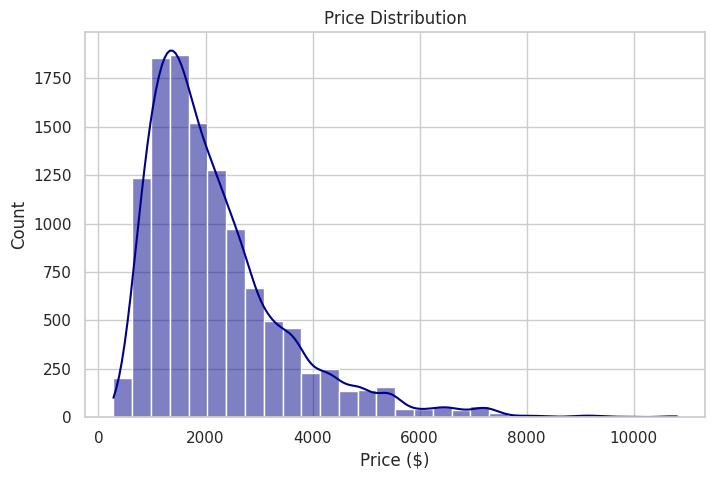

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Price ($)'], bins=30, kde=True, color='darkblue')
plt.title('Price Distribution')
plt.show()

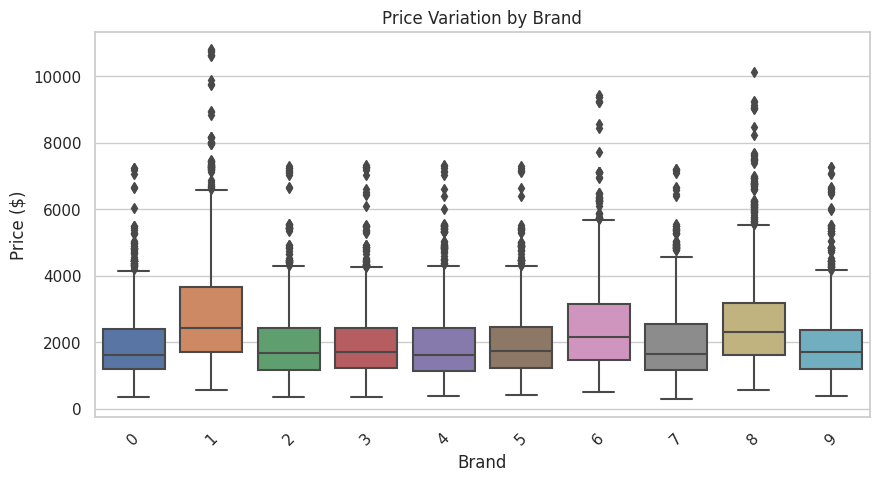

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Brand', y='Price ($)', data=df)
plt.xticks(rotation=45)
plt.title('Price Variation by Brand')
plt.show()

## Predictions

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
encoder = LabelEncoder()
df['Brand'] = encoder.fit_transform(df['Brand'])
df['Processor'] = encoder.fit_transform(df['Processor'])
df['GPU'] = encoder.fit_transform(df['GPU'])
df['Storage'] = encoder.fit_transform(df['Storage'])
df['Resolution'] = encoder.fit_transform(df['Resolution'])
df['Operating System'] = encoder.fit_transform(df['Operating System'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11768 entries, 0 to 11767
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 11768 non-null  int64  
 1   Processor             11768 non-null  int64  
 2   RAM (GB)              11768 non-null  int64  
 3   Storage               11768 non-null  int64  
 4   GPU                   11768 non-null  int64  
 5   Screen Size (inch)    11768 non-null  float64
 6   Resolution            11768 non-null  int64  
 7   Battery Life (hours)  11768 non-null  float64
 8   Weight (kg)           11768 non-null  float64
 9   Operating System      11768 non-null  int64  
 10  Price ($)             11768 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 1011.4 KB


In [18]:
x = df.drop(['Price ($)'], axis=1)
y = df['Price ($)']

In [19]:
x_train ,x_test , y_train,y_test = train_test_split(x,y, random_state = 23,test_size = 0.13)

In [20]:
rfr = RandomForestRegressor(n_estimators = 200)
model = rfr.fit(x_train,y_train)
model.score(x_test,y_test)

0.9013774033908958